## README

This project is presented in partial fulfillment of the course ***Computer Vision and Deep Learning for Medical Data Analysis Bootcamp** in the **Health Informatics Research Lab (HIRL).**


Project submitted by-

Md Tomal Ahmed Sajib (221-15-5406),
Dept. of CSE

---

## Project Methodology


**Phase I: Processing and Organizing Dataset**


---
1. Unzip the Training Dataset of original images and their corresponding masks
2. Separate the Masks from Original USG image and save them into another directory.
3. Sort/ Allign the masks with their corresponded USG images.
4. Count total masks and original images.
5. If there any multiple masks are detected, merge them into single mask.
6. Again check if the number of masks and their corresponded USG image is equal or not.
7. Preprocess,resize and enhance the training dataset as well as removing writings and artifacts.
8. Evaluate the processed images with previous unprocessed images through some common image quality metrices.
9. Save the processed images and delete the unprocessed images to clean memory.
10. Now, Masks and their corresponding Processed images are Ready as Training inputs for next phase.

**Phase II: Building Hybrid Segmentation Model**

---
1. Split the datast(Processed in Phase-I) into train and test sets.
2. Apply Spatial Attention.
3. Fed it to Convo2D Block attention.
4. Fed the extracted features into Unet Model Architecture.
5. Initialize the model and set hyperparameter.
6. A Hybrid Architecture is ready. Train the defined Model.
7. Now, The Hybrid model is successfully trained.
8. Save and preserve the generated model weights for further use.

**Phase III: Segmenting a different Breast USG image Dataset**

---
1. Unzip and clean the dataset which is to be used for segmenting ROI.
2. Load the dattaset for inspecting.
3. There found some images in the wrong class.eg. some malignant images are found in benign class and some benign images found in malignat class.
4. Transfer the miss-classed images to their correct class.
5. Preprocess the dataset in the same technique as mentioned in Phase-I, point 7.
6. Save the processed files and delete pervious unprocessed files.
7. Load trained weight generated from Hybrid Unet segmantation model.
8. Apply the model weights to segment ROI of Benign and Malignant tumor from breast USG images.
9. Inspect the segmentation masks for both benign and malignant classes.
9. ROIs are segmented successfully and saved as segmentation masks.
10. Now, perform Bitwise AND operation between segmentation masks and their corresponded proccessed images to locate the exact positions of tumors.
11. Save and Zip the result of point 11 for classification tasks.
12. ROI of a different Dataset is successfully segmented for a classification tasks.

**Phase IV: Classification of newly segmented dataset**

---
1. Unzip and Load the newly segmented dataset for classification.
2. Check if the classes are imbalance or not.
3. The imbalanceness of the classes are later handled through image augmentation during traing time.
4. Split the dataset into train, test and validation sets.
5. Initially applied a custom hybrid classification model-RkoNet13 for classification task but it poorly performed in validation accuracy.
6. Then some pre-trained Trasfer-Learnig models (VGG16, ResNet50, InceptionV3 and DenseNet121) are implemented for classification tasks.
7. The model performances are evaluated by Confusion Matrix, ROC-AUC curve, Training-Validation accurcy and loss curve.
8. Now, the best performing model can be considered for ablation study or as the base of a hybrid classification model.

## Phase I: Processing and Organizing Dataset

In [ ]:
#Bismillah

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# importing datset with mask images and unzipping
!unzip -u "/content/drive/MyDrive/Final Project CG Bootcamp/Datasets/Processed_BUSI_Corrected.zip" -d "/content/y"
print('\n\ndone!')

Archive:  /content/drive/MyDrive/Final Project CG Bootcamp/Datasets/Processed_BUSI_Corrected.zip
   creating: /content/y/Benign_Processed_images/
   creating: /content/y/Malignant_Processed_images/
  inflating: /content/y/Benign_Processed_images/benign (82).png  
  inflating: /content/y/Benign_Processed_images/benign (95).png  
  inflating: /content/y/Benign_Processed_images/benign (54).png  
  inflating: /content/y/Benign_Processed_images/benign (345).png  
  inflating: /content/y/Benign_Processed_images/benign (364).png  
  inflating: /content/y/Benign_Processed_images/benign (102).png  
  inflating: /content/y/Benign_Processed_images/benign (433).png  
  inflating: /content/y/Benign_Processed_images/benign (89).png  
  inflating: /content/y/Benign_Processed_images/benign (42).png  
  inflating: /content/y/Benign_Processed_images/benign (14).png  
  inflating: /content/y/Benign_Processed_images/benign (372).png  
  inflating: /content/y/Benign_Processed_images/benign (105).png  
  in

In [ ]:
# Deleting Normal Class as we dont need it
import os
import shutil

folder_path = "/content/y/BUSI_Corrected/normal"

# Check if folder exists before deleting
if os.path.exists(folder_path):
    shutil.rmtree(folder_path)
    print("Folder deleted successfully")
else:
    print("Folder does not exist")

Folder deleted successfully


In [ ]:
# Separating masked and original images
import os
import shutil

# Define the source directory containing images
source_dir = "/content/Dataset_BUSI_with_GT/benign"

# Define target directories
image_dir = os.path.join(source_dir, "images")
mask_dir = os.path.join(source_dir, "masks")

# Create target directories if they don't exist
os.makedirs(image_dir, exist_ok=True)
os.makedirs(mask_dir, exist_ok=True)

# Iterate through files in the source directory
for filename in os.listdir(source_dir):
    file_path = os.path.join(source_dir, filename)

    # Check if it's a file (not a directory)
    if os.path.isfile(file_path):
        if "mask" in filename.lower():  # Check if filename contains 'mask'
            shutil.move(file_path, os.path.join(mask_dir, filename))
        else:
            shutil.move(file_path, os.path.join(image_dir, filename))

print("Images and masks have been separated successfully!")

Images and masks have been separated successfully!


In [ ]:
# Cheking the number of Original image files and masks are same or not
import os

def count_files(folder_path, label):
    num_files = len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])
    print(f"Number of files in {label}: {num_files}")

# Define folder paths
folders = {
    "benign masks": "/content/Dataset_BUSI_with_GT/benign/masks",
    "benign images": "/content/Dataset_BUSI_with_GT/benign/images",
    "malignant masks": "/content/Dataset_BUSI_with_GT/malignant/masks",
    "malignant images": "/content/Dataset_BUSI_with_GT/malignant/images"
}

# Count and display file numbers
for label, path in folders.items():
    count_files(path, label)

Number of files in benign masks: 454
Number of files in benign images: 437
Number of files in malignant masks: 211
Number of files in malignant images: 210


In [ ]:
# Now merging multiple masks of a single image into a single corresponded mask

import os
import cv2
import numpy as np
from collections import defaultdict

def combine_masks(input_folder, output_folder):
    os.makedirs(output_folder, exist_ok=True)  # Ensure output folder exists

    masks_dict = defaultdict(list)

    # Categorize mask files by base image name
    for filename in os.listdir(input_folder):
        if filename.endswith('.png') and '_mask' in filename:
            base_name = filename.split('_mask')[0]
            masks_dict[base_name].append(filename)

    for base_name, mask_files in masks_dict.items():
        combined_mask = None

        # Sort mask filenames to ensure correct processing order
        mask_files.sort()

        for mask_file in mask_files:
            mask_path = os.path.join(input_folder, mask_file)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

            if mask is None:
                print(f"Warning: Could not read {mask_path}")
                continue

            if combined_mask is None:
                combined_mask = mask
            else:
                combined_mask = cv2.bitwise_or(combined_mask, mask)  # Combine masks

        if combined_mask is not None:
            output_filename = f"{base_name}_mask.png"
            output_path = os.path.join(output_folder, output_filename)
            cv2.imwrite(output_path, combined_mask)
            print(f'Combined mask saved: {output_path}')

# Example usage
input_folder = '/content/Dataset_BUSI_with_GT/malignant/masks'
output_folder = '/content/Dataset_BUSI_with_GT/malignant/processed_masks'
combine_masks(input_folder, output_folder)

Combined mask saved: /content/Dataset_BUSI_with_GT/malignant/processed_masks/malignant (43)_mask.png
Combined mask saved: /content/Dataset_BUSI_with_GT/malignant/processed_masks/malignant (160)_mask.png
Combined mask saved: /content/Dataset_BUSI_with_GT/malignant/processed_masks/malignant (24)_mask.png
Combined mask saved: /content/Dataset_BUSI_with_GT/malignant/processed_masks/malignant (37)_mask.png
Combined mask saved: /content/Dataset_BUSI_with_GT/malignant/processed_masks/malignant (114)_mask.png
Combined mask saved: /content/Dataset_BUSI_with_GT/malignant/processed_masks/malignant (102)_mask.png
Combined mask saved: /content/Dataset_BUSI_with_GT/malignant/processed_masks/malignant (135)_mask.png
Combined mask saved: /content/Dataset_BUSI_with_GT/malignant/processed_masks/malignant (197)_mask.png
Combined mask saved: /content/Dataset_BUSI_with_GT/malignant/processed_masks/malignant (30)_mask.png
Combined mask saved: /content/Dataset_BUSI_with_GT/malignant/processed_masks/malignant

In [ ]:
# Now checking again the nuber of masks matches with actual images after merging

def count_files_again(folder_path, label):
    num_files = len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])
    print(f"Number of files in {label}: {num_files}")

# Define folder paths
folders = {
    "benign masks": "/content/Dataset_BUSI_with_GT/benign/processed_masks",
    "benign images": "/content/Dataset_BUSI_with_GT/benign/images",
    "malignant masks": "/content/Dataset_BUSI_with_GT/malignant/processed_masks",
    "malignant images": "/content/Dataset_BUSI_with_GT/malignant/images"
}

# Count and display file numbers
for label, path in folders.items():
    count_files_again(path, label)

Number of files in benign masks: 437
Number of files in benign images: 437
Number of files in malignant masks: 210
Number of files in malignant images: 210


In [ ]:
# Removing the previous masks, keeping the merged masks

import os
import shutil
# List of folders to delete
folders = [
    "/content/Dataset_BUSI_with_GT/benign/masks",
    "/content/Dataset_BUSI_with_GT/malignant/masks"
]

# Loop through folders and delete if they exist
for folder_path in folders:
    if os.path.exists(folder_path):
        shutil.rmtree(folder_path)
        print(f"Folder deleted successfully: {folder_path}")
    else:
        print(f"Folder does not exist: {folder_path}")


Folder deleted successfully: /content/Dataset_BUSI_with_GT/benign/masks
Folder deleted successfully: /content/Dataset_BUSI_with_GT/malignant/masks


In [ ]:
!pip install keras_ocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 101.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 969.6/969.6 kB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 4.8 MB/s eta 0:00:00


In [ ]:
# Preprocessing Original images by removing artifacts and writing in the images and saving processed images

import cv2
import os
import numpy as np
import keras_ocr

def resize_image(image, size=(224, 224)):
    return cv2.resize(image, size, interpolation=cv2.INTER_AREA)

def remove_text(image):
    try:
        pipeline = keras_ocr.pipeline.Pipeline()
        predictions = pipeline.recognize([image])
        mask = np.zeros(image.shape[:2], dtype=np.uint8)

        for text, box in predictions[0]:
            box = np.array(box, dtype=np.int32)
            cv2.fillPoly(mask, [box], (255, 255, 255))

        inpainted_image = cv2.inpaint(image, mask, inpaintRadius=3, flags=cv2.INPAINT_NS)
        return inpainted_image
    except ValueError as e:
        return image

def remove_artifacts(image):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    return cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)

def remove_speckle_noise(image):
    return cv2.medianBlur(image, 3)

def preprocess_images(input_folder, output_folder):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    for filename in os.listdir(input_folder):
        if filename.endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(input_folder, filename)
            image = cv2.imread(img_path)

            resized = resize_image(image)
            text_removed = remove_text(resized)
            artifacts_removed = remove_artifacts(text_removed)
            final_image = remove_speckle_noise(artifacts_removed)

            output_path = os.path.join(output_folder, filename)
            cv2.imwrite(output_path, final_image)
            print(f'Processed: {filename}')

# Example usage
input_folder = '/content/Dataset_BUSI_with_GT/benign/images'
output_folder = '/content/Dataset_BUSI_with_GT/benign/Processed_images'
preprocess_images(input_folder, output_folder)

Looking for /root/.keras-ocr/craft_mlt_25k.h5
Processed: benign (155).png
Looking for /root/.keras-ocr/craft_mlt_25k.h5
Processed: benign (84).png
Looking for /root/.keras-ocr/craft_mlt_25k.h5
Processed: benign (200).png
Looking for /root/.keras-ocr/craft_mlt_25k.h5
Processed: benign (51).png
Looking for /root/.keras-ocr/craft_mlt_25k.h5
Processed: benign (339).png
Looking for /root/.keras-ocr/craft_mlt_25k.h5
Processed: benign (410).png
Looking for /root/.keras-ocr/craft_mlt_25k.h5
Processed: benign (423).png
Looking for /root/.keras-ocr/craft_mlt_25k.h5
Processed: benign (382).png
Looking for /root/.keras-ocr/craft_mlt_25k.h5
Processed: benign (358).png
Looking for /root/.keras-ocr/craft_mlt_25k.h5
Processed: benign (143).png
Looking for /root/.keras-ocr/craft_mlt_25k.h5
Processed: benign (320).png
Looking for /root/.keras-ocr/craft_mlt_25k.h5
Processed: benign (378).png
Looking for /root/.keras-ocr/craft_mlt_25k.h5
Processed: benign (416).png
Looking for /root/.keras-ocr/craft_mlt_2

In [ ]:
# Resizing the original images to 224,224 to compare with processed images

import os
import cv2

def resize_images(input_folder, output_folder, target_size=(224, 224)):
    """
    Resize all images in the input folder to the specified target size and save to output folder.

    Args:
        input_folder (str): Path to the folder containing images.
        output_folder (str): Path to the folder to save resized images.
        target_size (tuple): Desired image size (width, height), default (224, 224).
    """
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)  # Create output folder if it doesn't exist

    for filename in os.listdir(input_folder):
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)

        # Check if file is an image
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
            image = cv2.imread(input_path)  # Read image
            if image is not None:
                resized_image = cv2.resize(image, target_size)  # Resize image
                cv2.imwrite(output_path, resized_image)  # Save resized image
                print(f"Resized and saved: {output_path}")
            else:
                print(f"Error reading image: {input_path}")

# Example usage
input_folder = "/content/Dataset_BUSI_with_GT/malignant/images"  # Change to your folder path
output_folder = "/content/Dataset_BUSI_with_GT/malignant/resized_images"  # Output folder

resize_images(input_folder, output_folder)


Resized and saved: /content/Dataset_BUSI_with_GT/malignant/resized_images/malignant (45).png
Resized and saved: /content/Dataset_BUSI_with_GT/malignant/resized_images/malignant (108).png
Resized and saved: /content/Dataset_BUSI_with_GT/malignant/resized_images/malignant (25).png
Resized and saved: /content/Dataset_BUSI_with_GT/malignant/resized_images/malignant (87).png
Resized and saved: /content/Dataset_BUSI_with_GT/malignant/resized_images/malignant (73).png
Resized and saved: /content/Dataset_BUSI_with_GT/malignant/resized_images/malignant (149).png
Resized and saved: /content/Dataset_BUSI_with_GT/malignant/resized_images/malignant (65).png
Resized and saved: /content/Dataset_BUSI_with_GT/malignant/resized_images/malignant (82).png
Resized and saved: /content/Dataset_BUSI_with_GT/malignant/resized_images/malignant (131).png
Resized and saved: /content/Dataset_BUSI_with_GT/malignant/resized_images/malignant (123).png
Resized and saved: /content/Dataset_BUSI_with_GT/malignant/resized

In [ ]:
# Evaluating Processed images wrt. original images
# Extracting Image Quality Metrics for every class and saving it to a csv file

import os
import cv2
import csv
import numpy as np
from skimage.metrics import structural_similarity as ssim
from tqdm import tqdm  # Progress bar

def calculate_mse(image1, image2):
    """Calculate Mean Squared Error (MSE)."""
    return np.mean((image1 - image2) ** 2)

def calculate_rmse(mse):
    """Calculate Root Mean Squared Error (RMSE)."""
    return np.sqrt(mse)

def calculate_psnr(image1, image2):
    """Calculate Peak Signal-to-Noise Ratio (PSNR)."""
    mse = calculate_mse(image1, image2)
    if mse == 0:  # Avoid division by zero
        return float('inf')
    max_pixel = 255.0
    return 20 * np.log10(max_pixel / np.sqrt(mse))

def compare_images(ref_dir, comp_dir, output_csv):
    """
    Compare images in two directories and compute quality metrics.

    Args:
        ref_dir: Path to the directory holding reference/original images.
        comp_dir: Path to the directory holding processed images.
        output_csv: Path to save the CSV file with quality metrics.
    """
    class_name = "benign"  # Set class name manually

    ref_images = sorted(os.listdir(ref_dir))
    comp_images = sorted(os.listdir(comp_dir))

    if len(ref_images) != len(comp_images):
        print(f"Warning: Mismatch in image count for {class_name} (Original: {len(ref_images)}, Processed: {len(comp_images)})")

    with open(output_csv, mode='w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(["Class", "Image Name", "MSE", "RMSE", "PSNR", "SSIM"])

        for ref_image_name in tqdm(ref_images, desc=f"Processing {class_name} Images"):
            ref_image_path = os.path.join(ref_dir, ref_image_name)
            comp_image_path = os.path.join(comp_dir, ref_image_name)  # Assumes same filename in processed folder

            if not os.path.exists(comp_image_path):
                print(f"Skipping: {comp_image_path} not found")
                continue

            ref_image = cv2.imread(ref_image_path, cv2.IMREAD_GRAYSCALE)
            comp_image = cv2.imread(comp_image_path, cv2.IMREAD_GRAYSCALE)

            if ref_image is None or comp_image is None:
                print(f"Error reading: {ref_image_path} or {comp_image_path}")
                continue

            mse_value = calculate_mse(ref_image, comp_image)
            rmse_value = calculate_rmse(mse_value)
            psnr_value = calculate_psnr(ref_image, comp_image)
            ssim_value, _ = ssim(ref_image, comp_image, full=True)

            writer.writerow([class_name, ref_image_name, f"{mse_value:.4f}", f"{rmse_value:.4f}", f"{psnr_value:.4f}", f"{ssim_value:.4f}"])

    print(f"Metrics saved to {output_csv}")

# Paths to original and processed images for benign class
ref_dir = "/content/Dataset_BUSI_with_GT/malignant/resized_images"  # Original images
comp_dir = "/content/Dataset_BUSI_with_GT/malignant/Processed_images"  # Processed images
output_csv = "image_quality_metrics_malignant.csv"  # Output CSV file

if os.path.exists(ref_dir) and os.path.exists(comp_dir):
    compare_images(ref_dir, comp_dir, output_csv)
else:
    print("Skipping benign: Missing directories.")


Processing benign Images: 100%|██████████| 210/210 [00:01<00:00, 115.40it/s]

Metrics saved to image_quality_metrics_malignant.csv


In [ ]:
# Removing the previous unprocessed and resized image folders, keeping only processed images and processed masks

import os
import shutil
# List of folders to delete
folders = [
    "/content/BUSI_Corrected/normal",
]

# Loop through folders and delete if they exist
for folder_path in folders:
    if os.path.exists(folder_path):
        shutil.rmtree(folder_path)
        print(f"Folder deleted successfully: {folder_path}")
    else:
        print(f"Folder does not exist: {folder_path}")


Folder deleted successfully: /content/BUSI_Corrected/normal


In [ ]:
#zipping current
import shutil

def zip_folder(folder_path, output_zip):
    shutil.make_archive(output_zip, 'zip', folder_path)
    print(f'Folder zipped: {output_zip}.zip')

# Example usage
folder_to_zip = '/content/Dataset_BUSI_with_GT'  # Folder to be zipped
output_zip_path = '/content/Final_dataset'  # Output zip file (without .zip)
zip_folder(folder_to_zip, output_zip_path)


FileNotFoundError: [Errno 2] No such file or directory: 'exp data'

## Phase II: Building Hybrid Segmentation Model

In [ ]:
# Making essential imports
import os
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

In [ ]:
framObjTrain = {'img': [],
                'mask': []
               }

def LoadData(frameObj=None, imgPath=None, maskPath=None, shape=128):
    imgNames = os.listdir(imgPath)

    imgAddr = imgPath + '/'
    maskAddr = maskPath + '/'

    for imgName in imgNames:
        # Check if the file is an image file
        if imgName.endswith('.png'):
            img = plt.imread(imgAddr + imgName)
            maskName = imgName.split('.png')[0] + '_mask.png'
            mask = plt.imread(maskAddr + maskName)

            img = cv2.resize(img, (shape, shape))
            mask = cv2.resize(mask, (shape, shape))

            frameObj['img'].append(img)
            frameObj['mask'].append(mask)

    return frameObj

In [ ]:
# loading benign samples

framObjTrain = LoadData( framObjTrain, imgPath = '/content/x/malignant/Processed_images'
                        , maskPath = '/content/x/malignant/processed_masks'
                         , shape = 224)

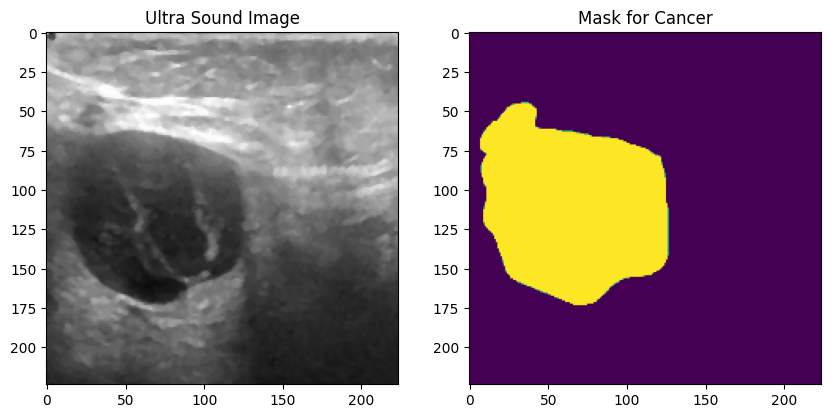

In [ ]:
## displaying data loaded by our function
plt.figure(figsize = (10, 7))
plt.subplot(1,2,1)
plt.imshow(framObjTrain['img'][5])
plt.title('Ultra Sound Image')
plt.subplot(1,2,2)
plt.imshow(framObjTrain['mask'][5])
plt.title('Mask for Cancer')
plt.show()

In [ ]:
pip install superml

In [ ]:
#train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(framObjTrain['img'], framObjTrain['mask'], test_size = 0.30, random_state = 42)

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models
from tensorflow.keras.utils import register_keras_serializable  # Import for registration

# Partial (Spatial) Attention
@register_keras_serializable()  # Register the custom layer
class PartialAttention(tf.keras.layers.Layer):
    def __init__(self, in_planes, **kwargs):
        super(PartialAttention, self).__init__(**kwargs)
        self.in_planes = in_planes

    def build(self, input_shape):
        self.conv1 = layers.Conv2D(self.in_planes // 8, kernel_size=1, activation='relu')
        self.conv2 = layers.Conv2D(self.in_planes, kernel_size=1, activation='sigmoid')

    def call(self, x):
        attention_map = self.conv1(x)
        attention_map = self.conv2(attention_map)
        return x * attention_map

    # Add get_config method to PartialAttention
    def get_config(self):
        config = super(PartialAttention, self).get_config()
        config.update({
            'in_planes': self.in_planes
        })
        return config

# Conv2D Block with Attention
def Conv2dBlock(inputTensor, numFilters, kernelSize=3, doBatchNorm=True):
    x = layers.Conv2D(filters=numFilters, kernel_size=(kernelSize, kernelSize),
                      kernel_initializer='he_normal', padding='same')(inputTensor)
    if doBatchNorm:
        x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters=numFilters, kernel_size=(kernelSize, kernelSize),
                      kernel_initializer='he_normal', padding='same')(x)
    if doBatchNorm:
        x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Apply Partial Attention
    x = PartialAttention(numFilters)(x)

    return x


In [ ]:
# U-Net Model Definition
def GiveMeUnet(inputImage, numFilters=16, droupouts=0.1, doBatchNorm=True):
    c1 = Conv2dBlock(inputImage, numFilters * 1, kernelSize=3, doBatchNorm=doBatchNorm)
    p1 = tf.keras.layers.MaxPooling2D((2,2))(c1)
    p1 = tf.keras.layers.Dropout(droupouts)(p1)

    c2 = Conv2dBlock(p1, numFilters * 2, kernelSize=3, doBatchNorm=doBatchNorm)
    p2 = tf.keras.layers.MaxPooling2D((2,2))(c2)
    p2 = tf.keras.layers.Dropout(droupouts)(p2)

    c3 = Conv2dBlock(p2, numFilters * 4, kernelSize=3, doBatchNorm=doBatchNorm)
    p3 = tf.keras.layers.MaxPooling2D((2,2))(c3)
    p3 = tf.keras.layers.Dropout(droupouts)(p3)

    c4 = Conv2dBlock(p3, numFilters * 8, kernelSize=3, doBatchNorm=doBatchNorm)
    p4 = tf.keras.layers.MaxPooling2D((2,2))(c4)
    p4 = tf.keras.layers.Dropout(droupouts)(p4)

    c5 = Conv2dBlock(p4, numFilters * 16, kernelSize=3, doBatchNorm=doBatchNorm)

    u6 = tf.keras.layers.Conv2DTranspose(numFilters*8, (3, 3), strides=(2, 2), padding='same')(c5)
    u6 = tf.keras.layers.concatenate([u6, c4])
    u6 = tf.keras.layers.Dropout(droupouts)(u6)
    c6 = Conv2dBlock(u6, numFilters * 8, kernelSize=3, doBatchNorm=doBatchNorm)

    u7 = tf.keras.layers.Conv2DTranspose(numFilters*4, (3, 3), strides=(2, 2), padding='same')(c6)
    u7 = tf.keras.layers.concatenate([u7, c3])
    u7 = tf.keras.layers.Dropout(droupouts)(u7)
    c7 = Conv2dBlock(u7, numFilters * 4, kernelSize=3, doBatchNorm=doBatchNorm)

    u8 = tf.keras.layers.Conv2DTranspose(numFilters*2, (3, 3), strides=(2, 2), padding='same')(c7)
    u8 = tf.keras.layers.concatenate([u8, c2])
    u8 = tf.keras.layers.Dropout(droupouts)(u8)
    c8 = Conv2dBlock(u8, numFilters * 2, kernelSize=3, doBatchNorm=doBatchNorm)

    u9 = tf.keras.layers.Conv2DTranspose(numFilters*1, (3, 3), strides=(2, 2), padding='same')(c8)
    u9 = tf.keras.layers.concatenate([u9, c1])
    u9 = tf.keras.layers.Dropout(droupouts)(u9)
    c9 = Conv2dBlock(u9, numFilters * 1, kernelSize=3, doBatchNorm=doBatchNorm)

    output = tf.keras.layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)
    model = tf.keras.Model(inputs=[inputImage], outputs=[output])
    return model

In [ ]:
batch_size = 16
inputs = tf.keras.layers.Input((224, 224, 3))
rkoshaheds_model = GiveMeUnet(inputs, droupouts= 0.3)
rkoshaheds_model.compile(optimizer = 'Adam', loss = 'binary_crossentropy', metrics = ['accuracy'] )
rkoshaheds_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_37 (Conv2D)        │ (None, 224, 224, 16)   │            448 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_18    │ (None, 224, 224, 16)   │             64 │ conv2d_37[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_18             │ (None, 224, 224, 16)   │              0 │ batch_normalization_1… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_38 (Conv2D)        │ (None, 224, 224, 16)   │          2,320 │ activation_18[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_19    │ (None, 224, 224, 16)   │             64 │ conv2d_38[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_19             │ (None, 224, 224, 16)   │              0 │ batch_normalization_1… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ partial_attention_9       │ (None, 224, 224, 16)   │             82 │ activation_19[0][0]    │
│ (PartialAttention)        │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_4           │ (None, 112, 112, 16)   │              0 │ partial_attention_9[0… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_8 (Dropout)       │ (None, 112, 112, 16)   │              0 │ max_pooling2d_4[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_41 (Conv2D)        │ (None, 112, 112, 32)   │          4,640 │ dropout_8[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_20    │ (None, 112, 112, 32)   │            128 │ conv2d_41[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_20             │ (None, 112, 112, 32)   │              0 │ batch_normalization_2… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_42 (Conv2D)        │ (None, 112, 112, 32)   │          9,248 │ activation_20[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_21    │ (None, 112, 112, 32)   │            128 │ conv2d_42[0][0]        │
│ (BatchNormalization) 

 Total params: 2,192,685 (8.36 MB)

 Trainable params: 2,189,741 (8.35 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [ ]:
hisVal = rkoshaheds_model.fit(np.array(X_train), np.array(y_train), batch_size = batch_size, epochs = 75)

Epoch 1/75


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_85']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


10/10 ━━━━━━━━━━━━━━━━━━━━ 60s 3s/step - accuracy: 0.3503 - loss: 0.7665
Epoch 2/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 41s 131ms/step - accuracy: 0.5860 - loss: 0.6624
Epoch 3/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - accuracy: 0.8487 - loss: 0.6008
Epoch 4/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 131ms/step - accuracy: 0.8533 - loss: 0.5666
Epoch 5/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step - accuracy: 0.8450 - loss: 0.5465
Epoch 6/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy: 0.8528 - loss: 0.5204
Epoch 7/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy: 0.8550 - loss: 0.5030
Epoch 8/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - accuracy: 0.8570 - loss: 0.4884
Epoch 9/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - accuracy: 0.8612 - loss: 0.4680
Epoch 10/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 139ms/step - accuracy: 0.8487 - loss: 0.4532
Epoch 11/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - accuracy: 0.8597 - loss: 0.4264
Epoch 12/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy:

In [ ]:
retVal = rkoshaheds_model.fit(np.array(X_test), np.array(y_test), epochs = 1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 56s 35s/step - accuracy: 0.9047 - loss: 0.2720


In [ ]:
#Saving Model
rkoshaheds_model.save('Malignant_BreastCancerSegmentor_75epochs.h5')

## Phase III: Segmenting a different Breast USG image Dataset

In [ ]:
# deleting normal class from test dataset

import os
import shutil
# List of folders to delete
folders = [
    "/content/y/BUSI_Corrected",
    #"/content/x/Malignant_Processed_images"
]

# Loop through folders and delete if they exist
for folder_path in folders:
    if os.path.exists(folder_path):
        shutil.rmtree(folder_path)
        print(f"Folder deleted successfully: {folder_path}")
    else:
        print(f"Folder does not exist: {folder_path}")

Folder deleted successfully: /content/y/BUSI_Corrected


In [ ]:
!pip install keras_ocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 969.6/969.6 kB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 4.5 MB/s eta 0:00:00


In [ ]:
# Preprocessing Original images by removing artifacts and writing in the images and saving processed images

import cv2
import os
import numpy as np
import keras_ocr

def resize_image(image, size=(224, 224)):
    return cv2.resize(image, size, interpolation=cv2.INTER_AREA)

def remove_text(image):
    try:
        pipeline = keras_ocr.pipeline.Pipeline()
        predictions = pipeline.recognize([image])
        mask = np.zeros(image.shape[:2], dtype=np.uint8)

        for text, box in predictions[0]:
            box = np.array(box, dtype=np.int32)
            cv2.fillPoly(mask, [box], (255, 255, 255))

        inpainted_image = cv2.inpaint(image, mask, inpaintRadius=3, flags=cv2.INPAINT_NS)
        return inpainted_image
    except ValueError as e:
        return image

def remove_artifacts(image):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    return cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)

def remove_speckle_noise(image):
    return cv2.medianBlur(image, 3)

def preprocess_images(input_folder, output_folder):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    for filename in os.listdir(input_folder):
        if filename.endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(input_folder, filename)
            image = cv2.imread(img_path)

            resized = resize_image(image)
            text_removed = remove_text(resized)
            artifacts_removed = remove_artifacts(text_removed)
            final_image = remove_speckle_noise(artifacts_removed)

            output_path = os.path.join(output_folder, filename)
            cv2.imwrite(output_path, final_image)
            print(f'Processed: {filename}')

# Example usage
input_folder = '/content/BUSI_Corrected/malignant'
output_folder = '/content/BUSI_Corrected/Malignant_Processed_images'
preprocess_images(input_folder, output_folder)

Looking for /root/.keras-ocr/craft_mlt_25k.h5
Processed: malignant (7).png
Looking for /root/.keras-ocr/craft_mlt_25k.h5
Processed: malignant (120).png
Looking for /root/.keras-ocr/craft_mlt_25k.h5
Processed: malignant (197).png
Looking for /root/.keras-ocr/craft_mlt_25k.h5
Processed: malignant (158).png
Looking for /root/.keras-ocr/craft_mlt_25k.h5
Processed: malignant (187).png
Looking for /root/.keras-ocr/craft_mlt_25k.h5
Processed: malignant (117).png
Looking for /root/.keras-ocr/craft_mlt_25k.h5
Processed: malignant (64).png
Looking for /root/.keras-ocr/craft_mlt_25k.h5
Processed: malignant (194).png
Looking for /root/.keras-ocr/craft_mlt_25k.h5
Processed: malignant (30).png
Looking for /root/.keras-ocr/craft_mlt_25k.h5
Processed: malignant (128).png
Looking for /root/.keras-ocr/craft_mlt_25k.h5
Processed: malignant (39).png
Looking for /root/.keras-ocr/craft_mlt_25k.h5
Processed: malignant (202).png
Looking for /root/.keras-ocr/craft_mlt_25k.h5
Processed: benign (392).png
Looking

KeyboardInterrupt: 

In [ ]:
# There are some benign images in malignant class and vice versa
# Transfering the images to their corresponded classes
import os
import shutil

# Define paths for benign and malignant class folders
benign_folder = "/content/BUSI_Corrected/Benign_Processed_images"
malignant_folder = "/content/BUSI_Corrected/Malignant_Processed_images"

# Function to move misclassified images to the correct folder
def correct_misclassified_images():
    # Check benign folder for misclassified malignant images
    for filename in os.listdir(benign_folder):
        if "malignant" in filename.lower():  # If "malignant" appears in the filename
            src_path = os.path.join(benign_folder, filename)
            dest_path = os.path.join(malignant_folder, filename)
            shutil.move(src_path, dest_path)
            print(f"Moved {filename} to Malignant folder.")

    # Check malignant folder for misclassified benign images
    for filename in os.listdir(malignant_folder):
        if "benign" in filename.lower():  # If "benign" appears in the filename
            src_path = os.path.join(malignant_folder, filename)
            dest_path = os.path.join(benign_folder, filename)
            shutil.move(src_path, dest_path)
            print(f"Moved {filename} to Benign folder.")

# Run the function
correct_misclassified_images()


Moved malignant (152).png to Malignant folder.
Moved malignant (74).png to Malignant folder.
Moved malignant (53).png to Malignant folder.
Moved malignant (61).png to Malignant folder.
Moved malignant (121).png to Malignant folder.
Moved malignant (27).png to Malignant folder.
Moved malignant (18).png to Malignant folder.
Moved malignant (52).png to Malignant folder.
Moved malignant (16).png to Malignant folder.
Moved malignant (116).png to Malignant folder.
Moved malignant (174).png to Malignant folder.
Moved malignant (112).png to Malignant folder.
Moved malignant (10).png to Malignant folder.
Moved malignant (26).png to Malignant folder.
Moved malignant (148).png to Malignant folder.
Moved malignant (73).png to Malignant folder.
Moved malignant (93).png to Malignant folder.
Moved malignant (28).png to Malignant folder.
Moved malignant (45).png to Malignant folder.
Moved benign (42).png to Benign folder.
Moved benign (360).png to Benign folder.
Moved benign (392).png to Benign folder

In [ ]:
import os
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# Load the UNet model
model = load_model('/content/Malignant_BreastCancerSegmentor_75epochs.h5')  # Change path as needed

# Define the input and output folders
input_folder = '/content/y/Malignant_Processed_images'
output_folder = '/content//Segmented_BUSI_Corrected/segmented_Malignant'

# Ensure the output folder exists
os.makedirs(output_folder, exist_ok=True)

# Get all image filenames in the input folder
image_filenames = [filename for filename in os.listdir(input_folder) if filename.endswith((".png", ".jpg"))]

# Process all images (removed random sampling)
for filename in image_filenames:
    # Read and preprocess the image
    image_path = os.path.join(input_folder, filename)
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Read as grayscale
    image = cv2.resize(image, (224, 224))  # Resize to model input size (224, 224)
    image = np.repeat(image[..., np.newaxis], 3, axis=-1) / 255.0  # Convert grayscale to RGB and normalize

    # Predict and save the segmented image
    segmented_image = model.predict(np.expand_dims(image, axis=0))[0, :, :, 0]  # Prediction and segmentation
    output_path = os.path.join(output_folder, filename)
    cv2.imwrite(output_path, (segmented_image > 0.5).astype(np.uint8) * 255)  # Save segmented image

    print(f"Saved segmented image: {filename}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Saved segmented image: malignant (7).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Saved segmented image: malignant (120).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Saved segmented image: malignant (197).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Saved segmented image: malignant (158).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Saved segmented image: malignant (187).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Saved segmented image: malignant (117).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Saved segmented image: malignant (64).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Saved segmented image: malignant (93).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Saved segmented image: malignant (194).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Saved segmented image: malignant (30).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Saved segmented image: malignant (128).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Saved segmented image: malignant (39).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/ste

In [ ]:
# Performing Bitwise AND Operation between segmented part and their corresponded processed images
import os
import cv2
import numpy as np

# Define the image and mask folders
image_folder = '/content/y/Malignant_Processed_images'  # Image folder path
mask_folder = '/content/Segmented_BUSI_Corrected/segmented_Malignant'  # Mask folder path
output_folder = '/content/Classification_dataset/malignant'  # Folder to save the results

# Ensure the output folder exists
os.makedirs(output_folder, exist_ok=True)

# Get all image filenames in the image folder
image_filenames = [filename for filename in os.listdir(image_folder) if filename.endswith((".png", ".jpg"))]

# Process all images in the image folder
for filename in image_filenames:
    # Construct the paths for the image and mask
    image_path = os.path.join(image_folder, filename)
    mask_path = os.path.join(mask_folder, filename)

    # Check if corresponding mask exists
    if os.path.exists(mask_path):
        # Read the image and mask
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Read as grayscale
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)  # Read as grayscale

        # Ensure the mask is binary (0 or 255)
        mask = (mask > 0).astype(np.uint8) * 255

        # Perform bitwise AND between the image and mask
        result = cv2.bitwise_and(image, mask)

        # Save the resulting image
        output_path = os.path.join(output_folder, filename)
        cv2.imwrite(output_path, result)

        print(f"Saved bitwise AND result: {output_path}")
    else:
        print(f"No corresponding mask found for {filename}")


Saved bitwise AND result: /content/Classification_dataset/malignant/malignant (7).png
Saved bitwise AND result: /content/Classification_dataset/malignant/malignant (120).png
Saved bitwise AND result: /content/Classification_dataset/malignant/malignant (197).png
Saved bitwise AND result: /content/Classification_dataset/malignant/malignant (158).png
Saved bitwise AND result: /content/Classification_dataset/malignant/malignant (187).png
Saved bitwise AND result: /content/Classification_dataset/malignant/malignant (117).png
Saved bitwise AND result: /content/Classification_dataset/malignant/malignant (64).png
Saved bitwise AND result: /content/Classification_dataset/malignant/malignant (93).png
Saved bitwise AND result: /content/Classification_dataset/malignant/malignant (194).png
Saved bitwise AND result: /content/Classification_dataset/malignant/malignant (30).png
Saved bitwise AND result: /content/Classification_dataset/malignant/malignant (128).png
Saved bitwise AND result: /content/Cl

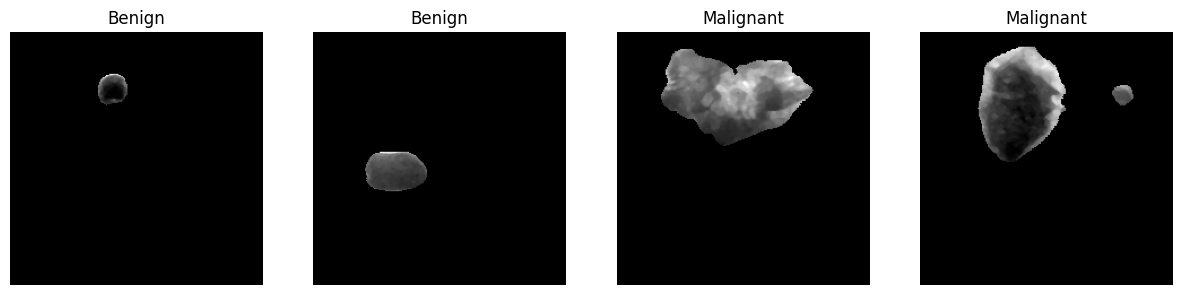

In [ ]:
# Visualizing some segmented dataset images
import os
import cv2
import random
import matplotlib.pyplot as plt

# Define the directories for Benign and Malignant images
benign_folder = "/content/Classification_dataset/benign"
malignant_folder = "/content/Classification_dataset/malignant"

# Function to get two random images from a folder
def get_random_images(folder, num_images=2):
    image_filenames = [f for f in os.listdir(folder) if f.endswith((".png", ".jpg", ".jpeg"))]
    if len(image_filenames) < num_images:
        print(f"Not enough images in {folder}")
        return []
    selected_images = random.sample(image_filenames, num_images)  # Select 2 random images
    return [cv2.imread(os.path.join(folder, img), cv2.IMREAD_GRAYSCALE) for img in selected_images]

# Load two random images from each class
benign_images = get_random_images(benign_folder)
malignant_images = get_random_images(malignant_folder)

# Combine images for visualization
all_images = benign_images + malignant_images
titles = ["Benign", "Malignant"]

# Plot the images
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for i, ax in enumerate(axes):
    ax.imshow(all_images[i], cmap='gray')
    ax.set_title(titles[i])
    ax.axis("off")

plt.show()



In [ ]:
# Zipping the processed dataset
#zipping current
import shutil

def zip_folder(folder_path, output_zip):
    shutil.make_archive(output_zip, 'zip', folder_path)
    print(f'Folder zipped: {output_zip}.zip')

# Example usage
folder_to_zip = '/content/Splitted'  # Folder to be zipped
output_zip_path = '/content/Classification_Dataset_Splitted'  # Output zip file (without .zip)
zip_folder(folder_to_zip, output_zip_path)

Folder zipped: /content/Classification_Dataset_Splitted.zip


## Phase IV: Classification of newly segmented dataset

In [ ]:
# importing datset with mask images and unzipping
!unzip -u "/content/Classification_Dataset_Splitted.zip" -d "/content/y"
print('\n\ndone!')

Archive:  /content/Classification_Dataset_Splitted.zip
   creating: /content/y/test/
   creating: /content/y/train/
   creating: /content/y/val/
   creating: /content/y/val/benign/
   creating: /content/y/val/malignant/
  inflating: /content/y/val/benign/benign (8).png  
  inflating: /content/y/val/benign/benign (434).png  
  inflating: /content/y/val/benign/benign (34).png  
  inflating: /content/y/val/benign/benign (135).png  
  inflating: /content/y/val/benign/benign (265).png  
  inflating: /content/y/val/benign/benign (341).png  
  inflating: /content/y/val/benign/benign (133).png  
  inflating: /content/y/val/benign/benign (284).png  
  inflating: /content/y/val/benign/benign (7).png  
  inflating: /content/y/val/benign/benign (50).png  
  inflating: /content/y/val/benign/benign (200).png  
  inflating: /content/y/val/benign/benign (231).png  
  inflating: /content/y/val/benign/benign (202).png  
  inflating: /content/y/val/benign/benign (363).png  
  inflating: /content/y/val/be

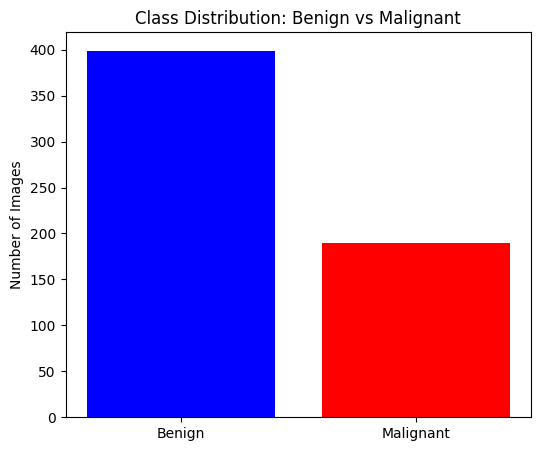

Benign Images: 399
Malignant Images: 190
⚠️ The dataset is imbalanced.


In [ ]:
#Checking the Classes are imbalanced or not
import os
import matplotlib.pyplot as plt

# Define the directories for Benign and Malignant images
benign_folder = "/content/Classification_dataset/benign"
malignant_folder = "/content/Classification_dataset/malignant"
# Count the number of images in each class
num_benign = len([f for f in os.listdir(benign_folder) if f.endswith((".png", ".jpg", ".jpeg"))])
num_malignant = len([f for f in os.listdir(malignant_folder) if f.endswith((".png", ".jpg", ".jpeg"))])

# Plot class distribution
plt.figure(figsize=(6, 5))
plt.bar(["Benign", "Malignant"], [num_benign, num_malignant], color=["blue", "red"])
plt.ylabel("Number of Images")
plt.title("Class Distribution: Benign vs Malignant")
plt.show()

# Print results
print(f"Benign Images: {num_benign}")
print(f"Malignant Images: {num_malignant}")

# Check if the classes are imbalanced
imbalance_ratio = max(num_benign, num_malignant) / min(num_benign, num_malignant) if min(num_benign, num_malignant) > 0 else float('inf')
if imbalance_ratio > 1.5:  # Threshold for imbalance
    print("⚠️ The dataset is imbalanced.")
else:
    print("✅ The dataset is balanced.")


In [ ]:
pip install split-folders

In [ ]:
import cv2
import numpy as np
import glob
import os
import splitfolders
import os

input_folder="/content/Classification_dataset"

output="/content/op"

splitfolders.ratio(input_folder, output, seed=42, ratio=(0.70,0.15,0.15)) ### train 75%, val 15%, test 10%

Copying files: 589 files [00:00, 9496.67 files/s]


In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.layers import BatchNormalization, LSTM, GlobalAveragePooling1D, MaxPooling2D, ZeroPadding2D, Conv2D, GlobalAveragePooling2D, Dense, Flatten, Concatenate, Reshape
import matplotlib.pyplot as plt

from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications import DenseNet201

from tensorflow.keras.layers import Input, Lambda, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img
from tensorflow.keras.models import Sequential
import numpy as np
from glob import glob

import keras.backend as K
from keras.models import Sequential
from keras.layers import Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger
import tensorflow as tf

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def RkoNet13(input_shape=(None, None, 3)):
    model = models.Sequential()

    # Block 1
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape))
    model.add(layers.MaxPooling2D((2, 2)))

    # Block 2
    model.add(layers.Conv2D(64, (5, 5), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))

    # Block 3
    model.add(layers.Conv2D(64, (5, 5), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))

    # Block 4
    model.add(layers.Conv2D(128, (5, 5), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))

    # Block 5
    model.add(layers.Conv2D(256, (5, 5), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))

    # Fully Connected Layers
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(2, activation='sigmoid'))  # Assuming binary classification

    return model

# Create and compile the model
model = RkoNet13(input_shape=(224, 224, 3))  # Example input shape
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Summary of the model
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_177 (Conv2D)                  │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_178 (Conv2D)                  │ (None, 112, 112, 64)        │          51,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_14 (MaxPooling2D)      │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_179 (Conv2D)                  │ (None, 56, 56, 64)          │         102,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_15 (MaxPooling2D)      │ (None, 28, 28, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_180 (Conv2D)                  │ (None, 28, 28, 128)         │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_16 (MaxPooling2D)      │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_181 (Conv2D)                  │ (None, 14, 14, 256)         │         819,456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_17 (MaxPooling2D)      │ (None, 7, 7, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_14 (Flatten)                 │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_29 (Dense)                     │ (None, 512)                 │       6,423,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_18 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_19 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ (None, 2)                   │             514 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,733,890 (29.50 MB)

 Trainable params: 7,733,890 (29.50 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
### image datagenerator
train_datagen = ImageDataGenerator(
    rotation_range=20,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
)

val_datagen = ImageDataGenerator(rescale = 1./255)

training_set = train_datagen.flow_from_directory('/content/Splitted/train',
                                                 target_size = (224,224),
                                                 batch_size = 16,
                                                 class_mode = 'categorical')

val_set = val_datagen.flow_from_directory('/content/Splitted/val',
                                            target_size = (224,224),
                                            batch_size = 16,
                                            class_mode = 'categorical')

test_datagen = ImageDataGenerator(rescale = 1./255)

test_set = test_datagen.flow_from_directory('/content/Splitted/test',
                                            target_size = (224,224),
                                            batch_size = 16,
                                            class_mode = 'categorical')

Found 412 images belonging to 2 classes.
Found 87 images belonging to 2 classes.
Found 90 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger

# Define the correct filepath ending in `.weights.h5`
filepath = "/content/classification model.weights.h5"

# Define the ModelCheckpoint
checkpoint1 = ModelCheckpoint(filepath, monitor='val_accuracy', verbose=1,
                               save_weights_only=True, save_best_only=False, mode='max')

# Define the CSVLogger
log_csv = CSVLogger('/content/classification model.csv', separator=',', append=False)


# List of callbacks
callbacks_list = [checkpoint1, log_csv]

steps_per_epoch = len(training_set)
validation_steps = len(val_set)

r = model.fit(
    training_set,
    epochs=75,
    validation_data=val_set,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks_list
)

Epoch 1/75
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.5509 - loss: 2.6589
Epoch 1: saving model to /content/classification model.weights.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 343ms/step - accuracy: 0.5541 - loss: 2.6123 - val_accuracy: 0.6782 - val_loss: 0.6508
Epoch 2/75
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.7224 - loss: 0.5593
Epoch 2: saving model to /content/classification model.weights.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 191ms/step - accuracy: 0.7255 - loss: 0.5555 - val_accuracy: 0.6782 - val_loss: 1.6525
Epoch 3/75
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.8561 - loss: 0.3101
Epoch 3: saving model to /content/classification model.weights.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 249ms/step - accuracy: 0.8564 - loss: 0.3102 - val_accuracy: 0.6782 - val_loss: 2.0140
Epoch 4/75
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.8898 - loss: 0.2632
Epoch 4: saving model to /content/classification model.weights.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 190ms/step

### Implementing Transfer Learning Models

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input, Lambda, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img
from tensorflow.keras.models import Sequential
import numpy as np
from glob import glob

import keras.backend as K
from keras.models import Sequential
from keras.layers import Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger
from tensorflow.keras.applications.vgg16 import VGG16
import tensorflow as tf

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define dataset paths
train_dir = "/content/y/train"
val_dir = "/content/y/val"
test_dir = "/content/y/test"

# Define ImageDataGenerator with preprocessing
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load datasets efficiently
training_set = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    shuffle=True
)

val_set = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)

test_set = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)

Found 412 images belonging to 2 classes.
Found 87 images belonging to 2 classes.
Found 90 images belonging to 2 classes.


### VGG16

In [ ]:
#VGG16
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout # Import GlobalAveragePooling2D
from tensorflow.keras.models import Model
import tensorflow as tf

base_model_vgg16 = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

base_model_vgg16.trainable = False

x = base_model_vgg16.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
output = Dense(2, activation='softmax')(x)

vgg16_model = Model(inputs=base_model_vgg16.input, outputs=output)
vgg16_model.summary()

vgg16_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate =0.001),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_3           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 512)                 │              

 Total params: 14,715,714 (56.14 MB)

 Trainable params: 1,026 (4.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
import os

# Create output directory if it doesn't exist
output_dir = "/content/"
os.makedirs(output_dir, exist_ok=True)

# Filepaths for saving weights and logs
weights_filepath = os.path.join(output_dir, "VGG16.weights.h5")
log_csv_filepath = os.path.join(output_dir, "VGG16.csv")

# Define the ModelCheckpoint
checkpoint1 = ModelCheckpoint(
    weights_filepath,
    monitor='val_accuracy',
    verbose=1,
    save_weights_only=True,
    save_best_only=True,
    mode='max'
)

# Define the CSVLogger
log_csv = CSVLogger(log_csv_filepath, separator=',', append=False)

# List of callbacks
callbacks_list = [checkpoint1, log_csv]

# Function to save training history
def save_training_history(history, filename="training_history.csv"):
    history_df = pd.DataFrame({
        "epoch": range(1, len(history.history['accuracy']) + 1),
        "accuracy": history.history['accuracy'],
        "loss": history.history['loss'],
        "val_accuracy": history.history['val_accuracy'],
        "val_loss": history.history['val_loss']
    })
    history_df.to_csv(filename, index=False)

In [ ]:
# Fit the model with dynamically calculated steps
r = vgg16_model.fit(
    training_set,
    epochs=100,
    validation_data=val_set,
    #steps_per_epoch=steps_per_epoch,
    #validation_steps=validation_steps,
    callbacks=callbacks_list
)

Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.4568 - loss: 0.7628
Epoch 1: val_accuracy improved from -inf to 0.67816, saving model to /content/VGG16.weights.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 600ms/step - accuracy: 0.4608 - loss: 0.7604 - val_accuracy: 0.6782 - val_loss: 0.5940
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.7105 - loss: 0.5687
Epoch 2: val_accuracy improved from 0.67816 to 0.72414, saving model to /content/VGG16.weights.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - accuracy: 0.7101 - loss: 0.5688 - val_accuracy: 0.7241 - val_loss: 0.5247
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.7471 - loss: 0.5322
Epoch 3: val_accuracy improved from 0.72414 to 0.74713, saving model to /content/VGG16.weights.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - accuracy: 0.7476 - loss: 0.5316 - val_accuracy: 0.7471 - val_loss: 0.4752
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.8289 - loss: 0.4476
Epoch 4: val

In [ ]:
# Load weights
vgg16_model.load_weights('/content/VGG16.weights.h5')  ### Load weights from the .weights.h5 file

# Evaluate the model
preds = vgg16_model.evaluate(test_set)

# Print results
print("Loss = " + str(preds[0]))
print("Test Accuracy = " + str(preds[1]))

6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9544 - loss: 0.2034
Loss = 0.27880731225013733
Test Accuracy = 0.9222221970558167


Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 181ms/step


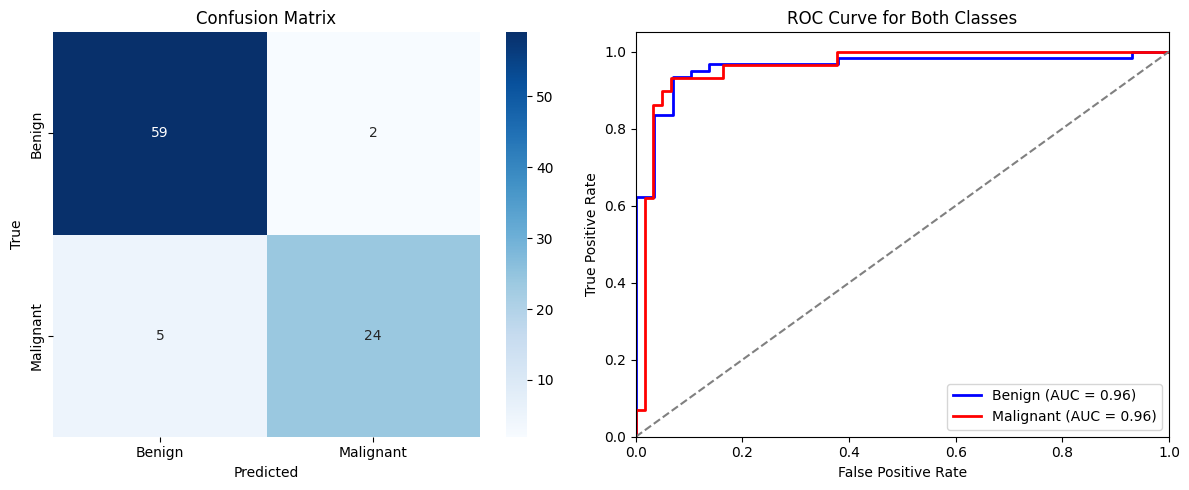

Classification Report:
               precision    recall  f1-score   support

      Benign       0.92      0.97      0.94        61
   Malignant       0.92      0.83      0.87        29

    accuracy                           0.92        90
   macro avg       0.92      0.90      0.91        90
weighted avg       0.92      0.92      0.92        90



In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Check GPU availability
print("Available GPUs:", tf.config.list_physical_devices('GPU'))

# Predict in batches (faster execution)
y_pred = vgg16_model.predict(test_set, verbose=1)  # Get predicted probabilities
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Get true labels efficiently
try:
    y_true_classes = test_set.labels  # Faster if available
except AttributeError:
    y_true = np.concatenate([y for _, y in test_set], axis=0)
    y_true_classes = np.argmax(y_true, axis=1)

# Compute confusion matrix
confusion_mat = confusion_matrix(y_true_classes, y_pred_classes)

# Compute ROC curve and AUC score for both classes
fpr = {}  # False positive rate
tpr = {}  # True positive rate
roc_auc = {}  # AUC score

n_classes = y_pred.shape[1]  # Number of classes (assuming one-hot encoded labels)

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_classes == i, y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

# Plot Confusion Matrix
sns.heatmap(confusion_mat, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign", "Malignant"],
            yticklabels=["Benign", "Malignant"], ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix')

# Plot ROC Curves for Both Classes
axes[1].plot(fpr[0], tpr[0], color='blue', lw=2, label=f'Benign (AUC = {roc_auc[0]:.2f})')
axes[1].plot(fpr[1], tpr[1], color='red', lw=2, label=f'Malignant (AUC = {roc_auc[1]:.2f})')
axes[1].plot([0, 1], [0, 1], color='grey', linestyle='--')  # Diagonal line

axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve for Both Classes')
axes[1].legend(loc='lower right')

# Show combined plots
plt.tight_layout()
plt.show()

# Print classification report
print("Classification Report:\n", classification_report(y_true_classes, y_pred_classes, target_names=["Benign", "Malignant"]))



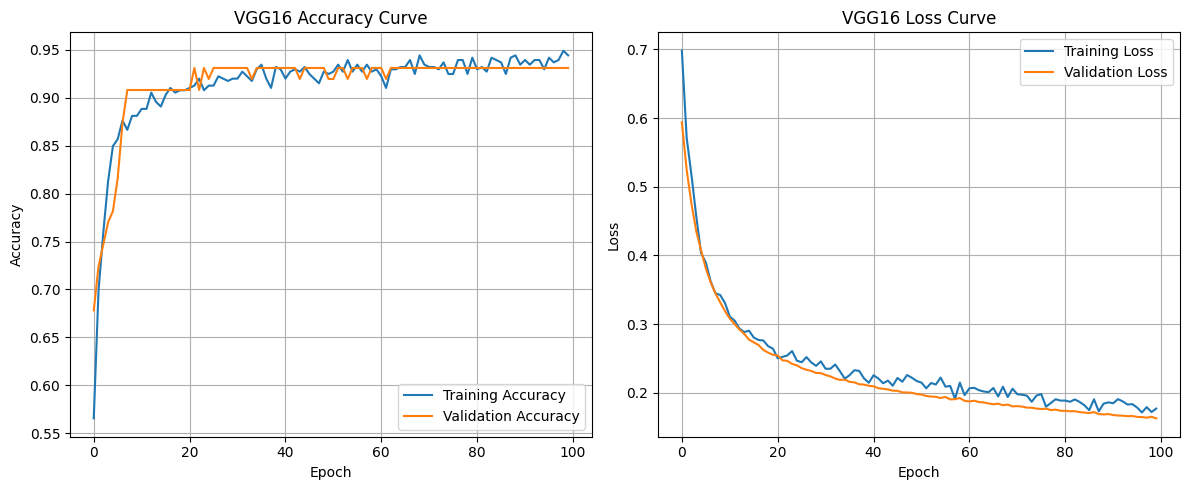

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data from CSV file
data = pd.read_csv('/content/VGG16.csv')  # Updated filename

# Create subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Accuracy Curve
axes[0].plot(data['epoch'], data['accuracy'], label='Training Accuracy')
axes[0].plot(data['epoch'], data['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('VGG16 Accuracy Curve')  # Updated title
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Plot Loss Curve
axes[1].plot(data['epoch'], data['loss'], label='Training Loss')
axes[1].plot(data['epoch'], data['val_loss'], label='Validation Loss')
axes[1].set_title('VGG16 Loss Curve')  # Updated title
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

# Adjust layout and show plot
plt.tight_layout()
plt.show()

### ResNet50

In [ ]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout # Import GlobalAveragePooling2D
from tensorflow.keras.models import Model
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50

base_model_ResNet50 = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

base_model_ResNet50.trainable = False

x = base_model_ResNet50.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
output = Dense(2, activation='softmax')(x)

ResNet50_model = Model(inputs=base_model_ResNet50.input, outputs=output)
ResNet50_model.summary()

ResNet50_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate =0.001),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer_5[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)             

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
import os

# Create output directory if it doesn't exist
output_dir = "/content/"
os.makedirs(output_dir, exist_ok=True)

# Filepaths for saving weights and logs
weights_filepath = os.path.join(output_dir, "ResNet50.weights.h5")
log_csv_filepath = os.path.join(output_dir, "ResNet50.csv")

# Define the ModelCheckpoint
checkpoint1 = ModelCheckpoint(
    weights_filepath,
    monitor='val_accuracy',
    verbose=1,
    save_weights_only=True,
    save_best_only=True,
    mode='max'
)

# Define the CSVLogger
log_csv = CSVLogger(log_csv_filepath, separator=',', append=False)

# List of callbacks
callbacks_list = [checkpoint1, log_csv]

# Function to save training history
def save_training_history(history, filename="training_history.csv"):
    history_df = pd.DataFrame({
        "epoch": range(1, len(history.history['accuracy']) + 1),
        "accuracy": history.history['accuracy'],
        "loss": history.history['loss'],
        "val_accuracy": history.history['val_accuracy'],
        "val_loss": history.history['val_loss']
    })
    history_df.to_csv(filename, index=False)

In [ ]:
# Fit the model with dynamically calculated steps
r = ResNet50_model.fit(
    training_set,
    epochs=100,
    validation_data=val_set,
    #steps_per_epoch=steps_per_epoch,
    #validation_steps=validation_steps,
    callbacks=callbacks_list
)

Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.5700 - loss: 0.7272
Epoch 1: val_accuracy improved from -inf to 0.70115, saving model to /content/ResNet50.weights.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 21s 428ms/step - accuracy: 0.5718 - loss: 0.7250 - val_accuracy: 0.7011 - val_loss: 0.6211
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5863 - loss: 0.6599
Epoch 2: val_accuracy did not improve from 0.70115
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.5881 - loss: 0.6591 - val_accuracy: 0.6782 - val_loss: 0.5687
Epoch 3/100
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7004 - loss: 0.5816
Epoch 3: val_accuracy improved from 0.70115 to 0.71264, saving model to /content/ResNet50.weights.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.7016 - loss: 0.5816 - val_accuracy: 0.7126 - val_loss: 0.5470
Epoch 4/100
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7610 - loss: 0.5476
Epoch 4: val_accuracy did not improve from 0.71264
26/2

In [ ]:
# Load weights
ResNet50_model.load_weights('/content/ResNet50.weights.h5')  ### Load weights from the .weights.h5 file

# Evaluate the model
preds = ResNet50_model.evaluate(test_set)

# Print results
print("Loss = " + str(preds[0]))
print("Test Accuracy = " + str(preds[1]))

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 420ms/step - accuracy: 0.9550 - loss: 0.2010
Loss = 0.24059011042118073
Test Accuracy = 0.9222221970558167


Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 688ms/step


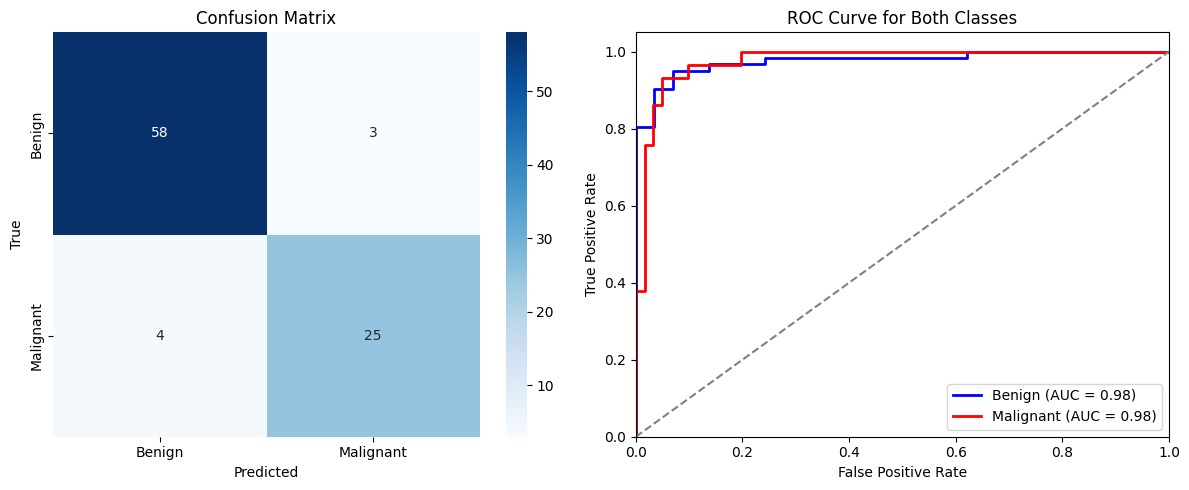

Classification Report:
               precision    recall  f1-score   support

      Benign       0.94      0.95      0.94        61
   Malignant       0.89      0.86      0.88        29

    accuracy                           0.92        90
   macro avg       0.91      0.91      0.91        90
weighted avg       0.92      0.92      0.92        90



In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Check GPU availability
print("Available GPUs:", tf.config.list_physical_devices('GPU'))

# Predict in batches (faster execution)
y_pred = ResNet50_model.predict(test_set, verbose=1)  # Get predicted probabilities
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Get true labels efficiently
try:
    y_true_classes = test_set.labels  # Faster if available
except AttributeError:
    y_true = np.concatenate([y for _, y in test_set], axis=0)
    y_true_classes = np.argmax(y_true, axis=1)

# Compute confusion matrix
confusion_mat = confusion_matrix(y_true_classes, y_pred_classes)

# Compute ROC curve and AUC score for both classes
fpr = {}  # False positive rate
tpr = {}  # True positive rate
roc_auc = {}  # AUC score

n_classes = y_pred.shape[1]  # Number of classes (assuming one-hot encoded labels)

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_classes == i, y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

# Plot Confusion Matrix
sns.heatmap(confusion_mat, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign", "Malignant"],
            yticklabels=["Benign", "Malignant"], ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix')

# Plot ROC Curves for Both Classes
axes[1].plot(fpr[0], tpr[0], color='blue', lw=2, label=f'Benign (AUC = {roc_auc[0]:.2f})')
axes[1].plot(fpr[1], tpr[1], color='red', lw=2, label=f'Malignant (AUC = {roc_auc[1]:.2f})')
axes[1].plot([0, 1], [0, 1], color='grey', linestyle='--')  # Diagonal line

axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve for Both Classes')
axes[1].legend(loc='lower right')

# Show combined plots
plt.tight_layout()
plt.show()

# Print classification report
print("Classification Report:\n", classification_report(y_true_classes, y_pred_classes, target_names=["Benign", "Malignant"]))


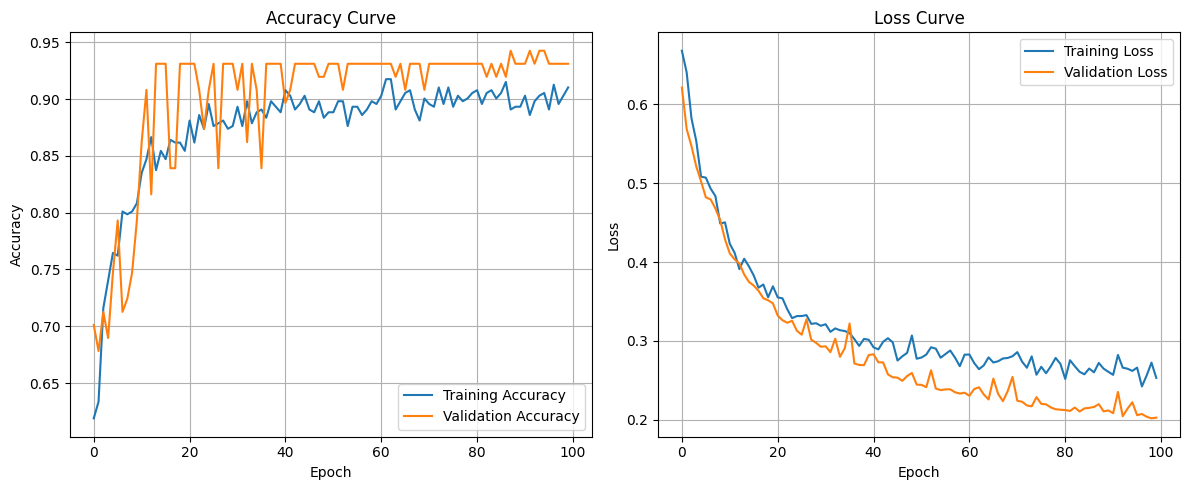

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data from CSV file
data = pd.read_csv('/content/ResNet50.csv')

# Create subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Accuracy Curve
axes[0].plot(data['epoch'], data['accuracy'], label='Training Accuracy')
axes[0].plot(data['epoch'], data['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Accuracy Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Plot Loss Curve
axes[1].plot(data['epoch'], data['loss'], label='Training Loss')
axes[1].plot(data['epoch'], data['val_loss'], label='Validation Loss')
axes[1].set_title('Loss Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

# Adjust layout and show plot
plt.tight_layout()
plt.show()


### InceptionV3

In [ ]:
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
import tensorflow as tf

# Load pre-trained InceptionV3 model (without top layers)
base_model_InceptionV3 = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the pre-trained model layers
base_model_InceptionV3.trainable = False

# Add custom layers on top
x = base_model_InceptionV3.output
x = GlobalAveragePooling2D()(x)  # Global Average Pooling Layer
x = Dropout(0.2)(x)  # Dropout for regularization
output = Dense(2, activation='softmax')(x)  # Output layer (2 classes: Benign & Malignant)

# Define the model
InceptionV3_model = Model(inputs=base_model_InceptionV3.input, outputs=output)

# Display model summary
InceptionV3_model.summary()

# Compile the model
InceptionV3_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                          loss='categorical_crossentropy',
                          metrics=['accuracy'])


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_94 (Conv2D)        │ (None, 111, 111, 32)   │            864 │ input_layer_6[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_94    │ (None, 111, 111, 32)   │             96 │ conv2d_94[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_94             │ (None, 111, 111, 32)   │              0 │ batch_normalization_9… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_95 (Conv2D)        │ (None, 109, 109, 32)   │          9,216 │ activation_94[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_95    │ (None, 109, 109, 32)   │             96 │ conv2d_95[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_95             │ (None, 109, 109, 32)   │              0 │ batch_normalization_9… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_96 (Conv2D)        │ (None, 109, 109, 64)   │         18,432 │ activation_95[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_96    │ (None, 109, 109, 64)   │            192 │ conv2d_96[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_96             │ (None, 109, 109, 64)   │              0 │ batch_normalization_9… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_4           │ (None, 54, 54, 64)     │              0 │ activation_96[0][0]    │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_97 (Conv2D)        │ (None, 54, 54, 80)     │          5,120 │ max_pooling2d_4[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_97    │ (None, 54, 54, 80)     │            240 │ conv2d_97[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_97             │ (None, 54, 54, 80)     │              0 │ batch_normalization_9… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_98 (Conv2D)   

 Total params: 21,806,882 (83.19 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
import os
import pandas as pd

# Create output directory if it doesn't exist
output_dir = "/content/"
os.makedirs(output_dir, exist_ok=True)

# Filepaths for saving weights and logs
weights_filepath = os.path.join(output_dir, "InceptionV3.weights.h5")
log_csv_filepath = os.path.join(output_dir, "InceptionV3.csv")

# Define the ModelCheckpoint
checkpoint = ModelCheckpoint(
    weights_filepath,
    monitor='val_accuracy',
    verbose=1,
    save_weights_only=True,
    save_best_only=True,
    mode='max'
)

# Define the CSVLogger
log_csv = CSVLogger(log_csv_filepath, separator=',', append=False)

# List of callbacks
callbacks_list = [checkpoint, log_csv]

# Function to save training history
def save_training_history(history, filename="training_history.csv"):
    history_df = pd.DataFrame({
        "epoch": range(1, len(history.history['accuracy']) + 1),
        "accuracy": history.history['accuracy'],
        "loss": history.history['loss'],
        "val_accuracy": history.history['val_accuracy'],
        "val_loss": history.history['val_loss']
    })
    history_df.to_csv(filename, index=False)



In [ ]:
# Fit the InceptionV3 model with dynamically calculated steps
r = InceptionV3_model.fit(
    training_set,
    epochs=100,
    validation_data=val_set,
    # steps_per_epoch=len(training_set),  # Uncomment if dynamic steps are needed
    # validation_steps=len(val_set),  # Uncomment if dynamic validation steps are needed
    callbacks=callbacks_list
)


Epoch 1/100
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.6672 - loss: 0.7259
Epoch 1: val_accuracy improved from -inf to 0.90805, saving model to /content/InceptionV3.weights.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 32s 802ms/step - accuracy: 0.6756 - loss: 0.7080 - val_accuracy: 0.9080 - val_loss: 0.2700
Epoch 2/100
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8760 - loss: 0.2990
Epoch 2: val_accuracy did not improve from 0.90805
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.8769 - loss: 0.2975 - val_accuracy: 0.8621 - val_loss: 0.2536
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8997 - loss: 0.2375
Epoch 3: val_accuracy improved from 0.90805 to 0.91954, saving model to /content/InceptionV3.weights.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.8997 - loss: 0.2375 - val_accuracy: 0.9195 - val_loss: 0.2247
Epoch 4/100
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9587 - loss: 0.1658
Epoch 4: val_accuracy did not improve from 0.9195

In [ ]:
# Load weights for InceptionV3
InceptionV3_model.load_weights('/content/InceptionV3.weights.h5')  ### Load the trained weights

# Evaluate the model on the test set
preds = InceptionV3_model.evaluate(test_set)

# Print evaluation results
print(f"Loss = {preds[0]:.4f}")
print(f"Test Accuracy = {preds[1]:.4%}")  # Display accuracy in percentage


6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 546ms/step - accuracy: 0.9337 - loss: 0.1947
Loss = 0.2821
Test Accuracy = 87.7778%


Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step


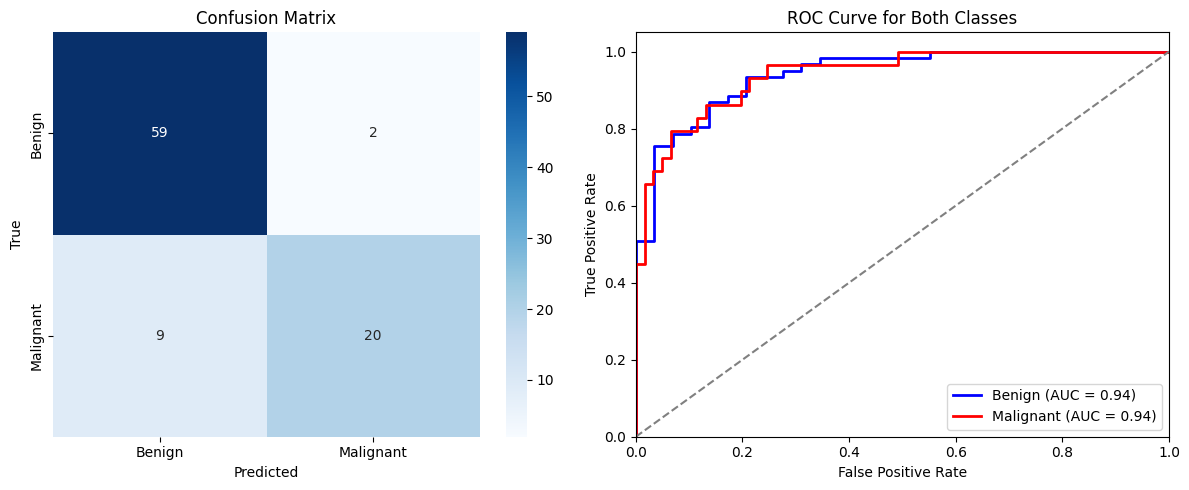

Classification Report:
               precision    recall  f1-score   support

      Benign       0.87      0.97      0.91        61
   Malignant       0.91      0.69      0.78        29

    accuracy                           0.88        90
   macro avg       0.89      0.83      0.85        90
weighted avg       0.88      0.88      0.87        90



In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Check GPU availability
print("Available GPUs:", tf.config.list_physical_devices('GPU'))

# Predict in batches (faster execution)
y_pred = InceptionV3_model.predict(test_set, verbose=1)  # Get predicted probabilities
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Get true labels efficiently
try:
    y_true_classes = test_set.labels  # Faster if available
except AttributeError:
    y_true = np.concatenate([y for _, y in test_set], axis=0)
    y_true_classes = np.argmax(y_true, axis=1)

# Compute confusion matrix
confusion_mat = confusion_matrix(y_true_classes, y_pred_classes)

# Compute ROC curve and AUC score for both classes
fpr = {}  # False positive rate
tpr = {}  # True positive rate
roc_auc = {}  # AUC score

n_classes = y_pred.shape[1]  # Number of classes (assuming one-hot encoded labels)

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_classes == i, y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

# Plot Confusion Matrix
sns.heatmap(confusion_mat, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign", "Malignant"],
            yticklabels=["Benign", "Malignant"], ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix')

# Plot ROC Curves for Both Classes
axes[1].plot(fpr[0], tpr[0], color='blue', lw=2, label=f'Benign (AUC = {roc_auc[0]:.2f})')
axes[1].plot(fpr[1], tpr[1], color='red', lw=2, label=f'Malignant (AUC = {roc_auc[1]:.2f})')
axes[1].plot([0, 1], [0, 1], color='grey', linestyle='--')  # Diagonal line

axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve for Both Classes')
axes[1].legend(loc='lower right')

# Show combined plots
plt.tight_layout()
plt.show()

# Print classification report
print("Classification Report:\n", classification_report(y_true_classes, y_pred_classes, target_names=["Benign", "Malignant"]))




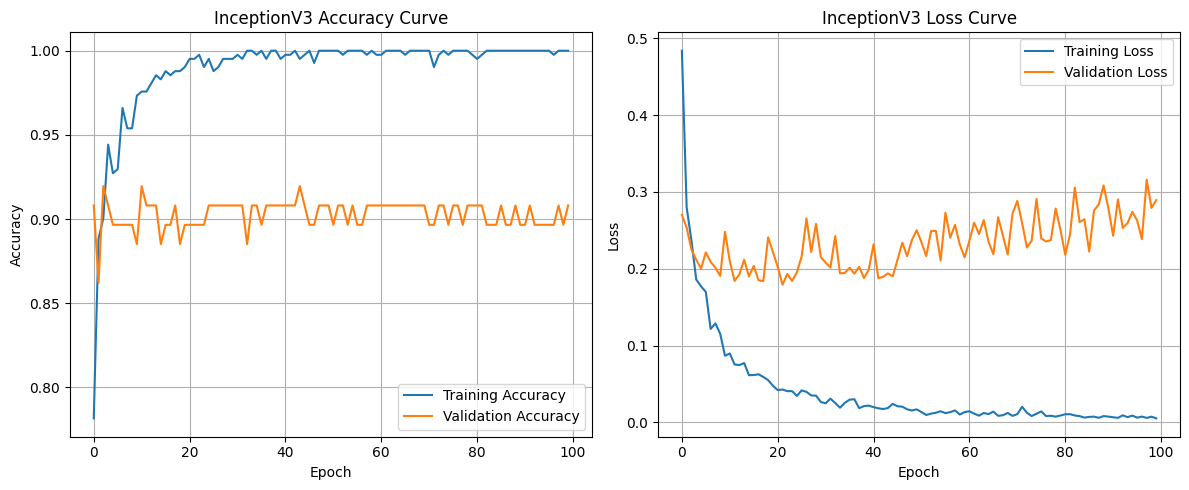

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data from CSV file
data = pd.read_csv('/content/InceptionV3.csv')  # Updated filename

# Create subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Accuracy Curve
axes[0].plot(data['epoch'], data['accuracy'], label='Training Accuracy')
axes[0].plot(data['epoch'], data['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('InceptionV3 Accuracy Curve')  # Updated title
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Plot Loss Curve
axes[1].plot(data['epoch'], data['loss'], label='Training Loss')
axes[1].plot(data['epoch'], data['val_loss'], label='Validation Loss')
axes[1].set_title('InceptionV3 Loss Curve')  # Updated title
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

# Adjust layout and show plot
plt.tight_layout()
plt.show()


### DenseNet121

In [ ]:
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
import tensorflow as tf

# Load the DenseNet121 base model with pre-trained ImageNet weights
base_model_densenet = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers
base_model_densenet.trainable = False

# Add custom classification layers
x = base_model_densenet.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
output = Dense(2, activation='softmax')(x)  # Adjust the output layer based on the number of classes

# Create the model
densenet_model = Model(inputs=base_model_densenet.input, outputs=output)

# Display model summary
densenet_model.summary()

# Compile the model
densenet_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d            │ (None, 230, 230, 3)    │              0 │ input_layer_7[0][0]    │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,408 │ zero_padding2d[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d_1          │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1 (MaxPooling2D)      │ (None, 56, 56, 64)     │              0 │ zero_padding2d_1[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_bn         │ (None, 56, 56, 64)     │            256 │ pool1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_0_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 128)    │          8,192 │ conv2_block1_0_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 128)    │            512 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 128)    │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 32)     │         36,864 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_concat       │ (None, 56, 56, 96)     │              0 │ pool1[0][0],           │
│ (Concatenate)             │                        │                │ conv2_block1_2_conv[0… │
├──────────────────────

 Total params: 7,039,554 (26.85 MB)

 Trainable params: 2,050 (8.01 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
import os
import pandas as pd  # Import pandas for saving training history

# Create output directory if it doesn't exist
output_dir = "/content/"
os.makedirs(output_dir, exist_ok=True)

# Filepaths for saving weights and logs
weights_filepath = os.path.join(output_dir, "DenseNet121.weights.h5")
log_csv_filepath = os.path.join(output_dir, "DenseNet121.csv")

# Define the ModelCheckpoint
checkpoint1 = ModelCheckpoint(
    weights_filepath,
    monitor='val_accuracy',
    verbose=1,
    save_weights_only=True,
    save_best_only=True,
    mode='max'
)

# Define the CSVLogger
log_csv = CSVLogger(log_csv_filepath, separator=',', append=False)

# List of callbacks
callbacks_list = [checkpoint1, log_csv]

# Function to save training history
def save_training_history(history, filename="training_history.csv"):
    history_df = pd.DataFrame({
        "epoch": range(1, len(history.history['accuracy']) + 1),
        "accuracy": history.history['accuracy'],
        "loss": history.history['loss'],
        "val_accuracy": history.history['val_accuracy'],
        "val_loss": history.history['val_loss']
    })
    history_df.to_csv(filename, index=False)


In [ ]:
# Fit the DenseNet121 model with dynamically calculated steps
r = densenet_model.fit(
    training_set,
    epochs=100,
    validation_data=val_set,
    # steps_per_epoch=steps_per_epoch,
    # validation_steps=validation_steps,
    callbacks=callbacks_list
)


Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 553ms/step - accuracy: 0.7218 - loss: 0.5652
Epoch 1: val_accuracy improved from -inf to 0.91954, saving model to /content/DenseNet121.weights.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.7247 - loss: 0.5605 - val_accuracy: 0.9195 - val_loss: 0.2435
Epoch 2/100
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8531 - loss: 0.3240
Epoch 2: val_accuracy did not improve from 0.91954
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.8552 - loss: 0.3211 - val_accuracy: 0.9080 - val_loss: 0.2494
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8765 - loss: 0.2746
Epoch 3: val_accuracy improved from 0.91954 to 0.93103, saving model to /content/DenseNet121.weights.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step - accuracy: 0.8766 - loss: 0.2747 - val_accuracy: 0.9310 - val_loss: 0.1757
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9425 - loss: 0.2030
Epoch 4: val_accuracy did not improve from 0.93103


In [ ]:
# Load weights
densenet_model.load_weights('/content/DenseNet121.weights.h5')  ### Load weights from the .weights.h5 file

# Evaluate the model
preds = densenet_model.evaluate(test_set)

# Print results
print("Loss = " + str(preds[0]))
print("Test Accuracy = " + str(preds[1]))


6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.9509 - loss: 0.1213
Loss = 0.16924919188022614
Test Accuracy = 0.9333333373069763


Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step


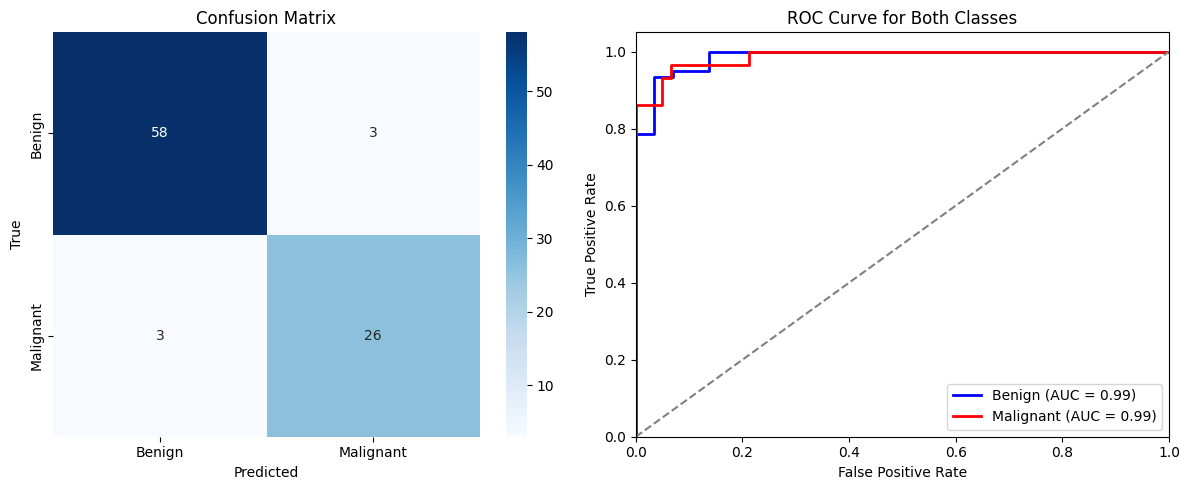

Classification Report:
               precision    recall  f1-score   support

      Benign       0.95      0.95      0.95        61
   Malignant       0.90      0.90      0.90        29

    accuracy                           0.93        90
   macro avg       0.92      0.92      0.92        90
weighted avg       0.93      0.93      0.93        90



In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Check GPU availability
print("Available GPUs:", tf.config.list_physical_devices('GPU'))

# Predict in batches (faster execution)
y_pred = densenet_model.predict(test_set, verbose=1)  # Get predicted probabilities
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Get true labels efficiently
try:
    y_true_classes = test_set.labels  # Faster if available
except AttributeError:
    y_true = np.concatenate([y for _, y in test_set], axis=0)
    y_true_classes = np.argmax(y_true, axis=1)

# Compute confusion matrix
confusion_mat = confusion_matrix(y_true_classes, y_pred_classes)

# Compute ROC curve and AUC score for both classes
fpr = {}  # False positive rate
tpr = {}  # True positive rate
roc_auc = {}  # AUC score

n_classes = y_pred.shape[1]  # Number of classes (assuming one-hot encoded labels)

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_classes == i, y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

# Plot Confusion Matrix
sns.heatmap(confusion_mat, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign", "Malignant"],
            yticklabels=["Benign", "Malignant"], ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix')

# Plot ROC Curves for Both Classes
axes[1].plot(fpr[0], tpr[0], color='blue', lw=2, label=f'Benign (AUC = {roc_auc[0]:.2f})')
axes[1].plot(fpr[1], tpr[1], color='red', lw=2, label=f'Malignant (AUC = {roc_auc[1]:.2f})')
axes[1].plot([0, 1], [0, 1], color='grey', linestyle='--')  # Diagonal line

axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve for Both Classes')
axes[1].legend(loc='lower right')

# Show combined plots
plt.tight_layout()
plt.show()

# Print classification report
print("Classification Report:\n", classification_report(y_true_classes, y_pred_classes, target_names=["Benign", "Malignant"]))


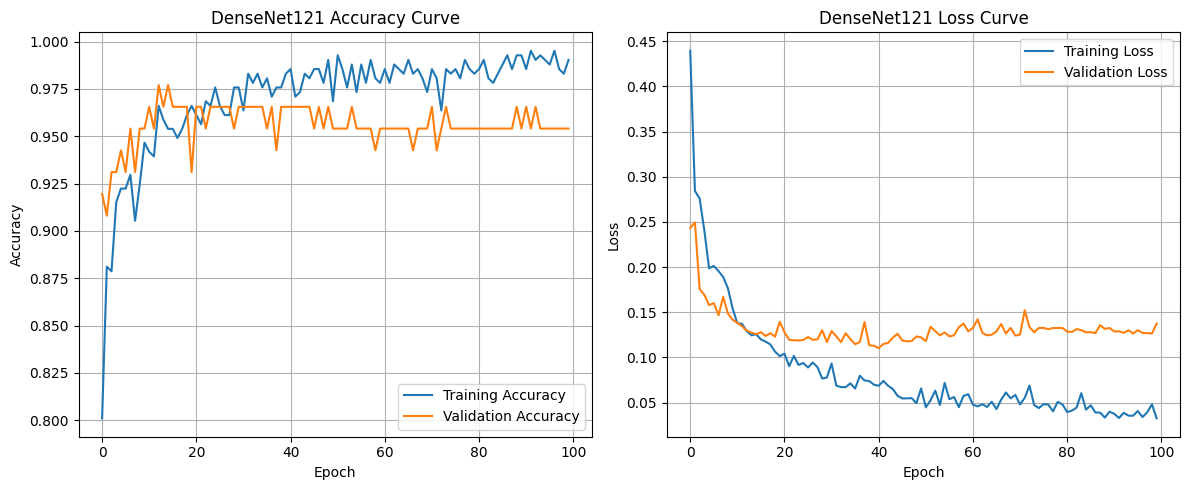

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data from CSV file
data = pd.read_csv('/content/DenseNet121.csv')  # Updated filename

# Create subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Accuracy Curve
axes[0].plot(data['epoch'], data['accuracy'], label='Training Accuracy')
axes[0].plot(data['epoch'], data['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('DenseNet121 Accuracy Curve')  # Updated title
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Plot Loss Curve
axes[1].plot(data['epoch'], data['loss'], label='Training Loss')
axes[1].plot(data['epoch'], data['val_loss'], label='Validation Loss')
axes[1].set_title('DenseNet121 Loss Curve')  # Updated title
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

# Adjust layout and show plot
plt.tight_layout()
plt.show()
